## **05. Interprétation & Recommandations - Conversion Rate Challenge**

**Objectif** : analyser les paramètres du modèle pour comprendre *pourquoi* un utilisateur convertit, et formuler des recommandations actionnables pour améliorer le taux de conversion.

**Plan du notebook** :
1. SHAP Feature Importance
2. Analyse des leviers business
3. Recommandations priorisées
4. Limites du modèle & pistes d'amélioration

*NB: SHAP (SHapley Additive exPlanations): C'est une méthode pour expliquer pourquoi un modèle a fait une prédiction, feature par feature.*

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

output_model_path = '../outputs/models'
output_data_path = '../outputs/data'
output_processed_path = '../outputs/processed'
output_image_path = '../outputs/images'
conversion_data_train_path = '../data/conversion_data_train.csv'
conversion_data_test_path = '../data/conversion_data_test.csv'

In [4]:
X_val   = np.load(f'{output_processed_path}/X_val.npy')
y_val   = pd.read_csv(f'{output_processed_path}/y_val.csv').squeeze()
df_train = pd.read_csv(f'{conversion_data_train_path}')

with open(f'{output_model_path}/best_model.pkl', 'rb') as f:
    saved = pickle.load(f)

model = saved['model']
threshold = saved['threshold']
name = saved['name']

feature_names = ['age', 'total_pages_visited', 'country', 'source',
                 'new_user', 'high_engagement', 'is_returning', 'is_china']

print(f'Modèle : {name} | Seuil : {threshold:.2f}')

Modèle : XGBoost | Seuil : 0.95


### **1. SHAP Feature Importance**

Les SHAP values mesurent la **contribution de chaque feature à chaque prédiction individuelle**. C'est plus fiable que la feature importance XGBoost classique (gain) car elles tiennent compte des interactions entre variables.

In [6]:
explainer  = shap.TreeExplainer(model)
idx_sample = np.random.RandomState(SEED).choice(len(X_val), 2000, replace=False)
X_sample   = X_val[idx_sample]
shap_values = explainer.shap_values(X_sample)

mean_shap = np.abs(shap_values).mean(axis=0)
print('Mean SHAP par feature (impact moyen sur la prédiction) :')
for name_f, val in sorted(zip(feature_names, mean_shap), key=lambda x: -x[1]):
    print(f'  {name_f:25s}: {val:.4f}')

Mean SHAP par feature (impact moyen sur la prédiction) :
  total_pages_visited      : 4.2464
  country                  : 0.9605
  age                      : 0.8412
  high_engagement          : 0.6466
  new_user                 : 0.4799
  source                   : 0.2540
  is_china                 : 0.1904
  is_returning             : 0.1289


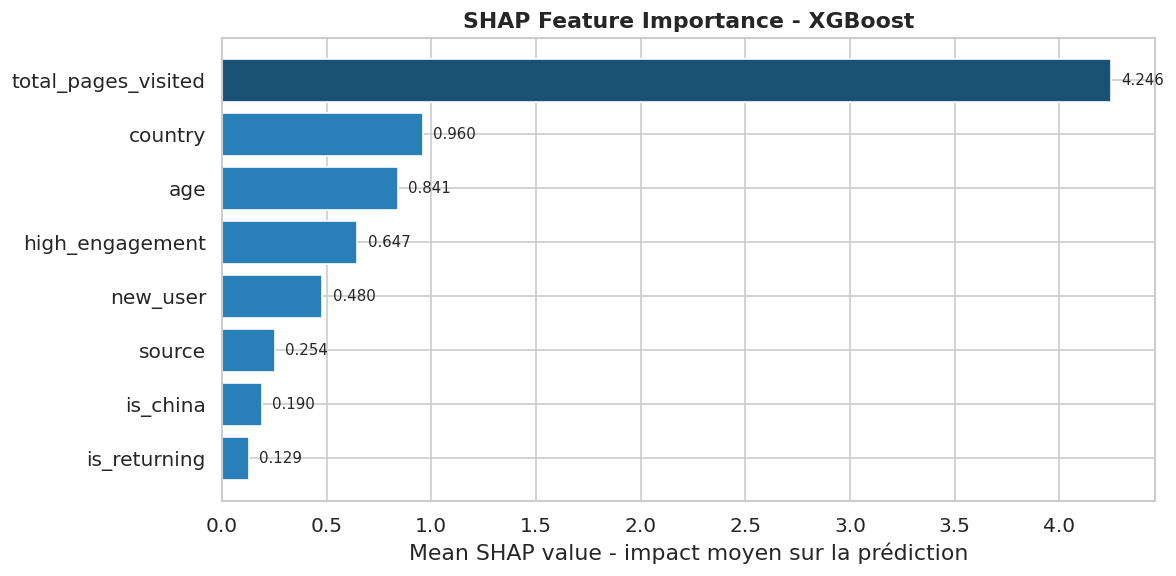

In [7]:
sorted_idx   = np.argsort(mean_shap)
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_vals  = mean_shap[sorted_idx]
colors = ['#1a5276' if v == mean_shap.max() else '#2980b9' for v in sorted_vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(sorted_names)), sorted_vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names)
ax.set_xlabel('Mean SHAP value - impact moyen sur la prédiction')
ax.set_title('SHAP Feature Importance - XGBoost', fontweight='bold')

for bar, v in zip(bars, sorted_vals):
    ax.text(v+0.05, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{output_image_path}/b01_shap_importance.png', bbox_inches='tight')
plt.show()

### **2. Analyse des leviers business**

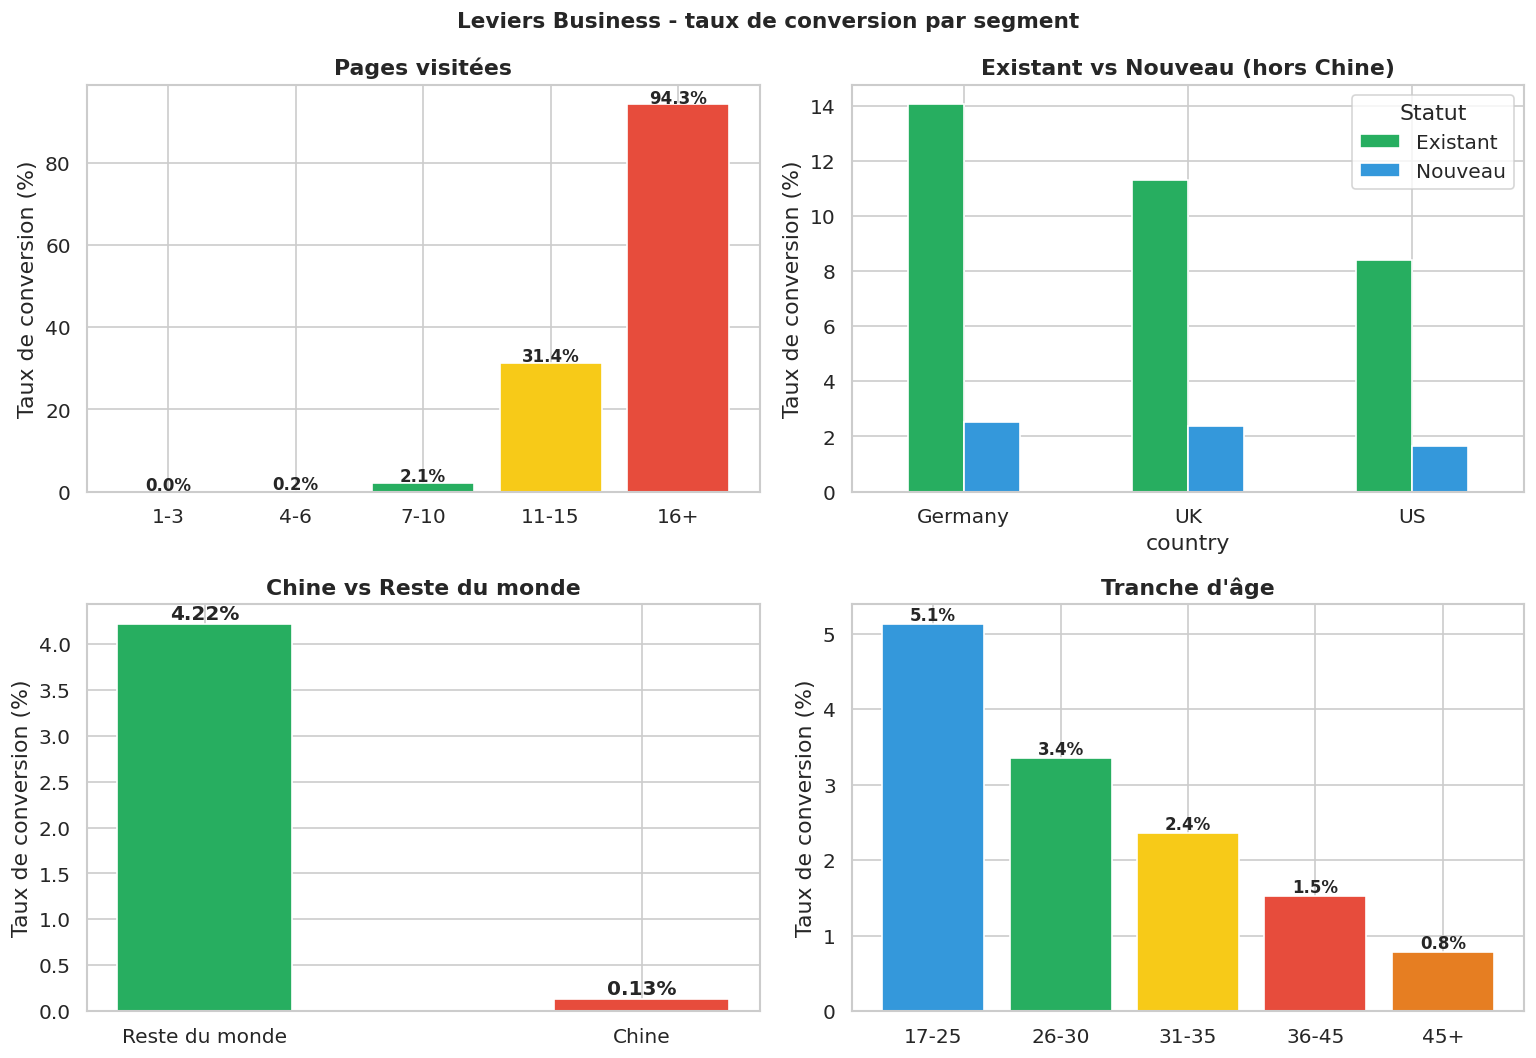

In [10]:
def add_features(df):
    df = df.copy()
    df['high_engagement'] = (df['total_pages_visited'] > 10).astype(int)
    df['is_returning'] = (1 - df['new_user']).astype(int)
    df['is_china'] = (df['country'] == 'China').astype(int)
    return df

df = add_features(df_train)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flat

# Palette light theme : blue, green, yellow, red
light_blue = "#3498db"
light_green = "#27ae60"
light_yellow = "#f7ca18"
light_red = "#e74c3c"

# Levier 1 : pages visitées
df['pages_bucket'] = pd.cut(df['total_pages_visited'],
    bins=[0,3,6,10,15,29], labels=['1-3','4-6','7-10','11-15','16+'])

conv_pages = df.groupby('pages_bucket', observed=True)['converted'].mean() * 100

bar_colors = [light_blue, "#5dade2", light_green, light_yellow, light_red]
bars = axes[0].bar(conv_pages.index, conv_pages.values, color=bar_colors, edgecolor='white')

axes[0].set_title('Pages visitées', fontweight='bold')
axes[0].set_ylabel('Taux de conversion (%)')

for bar, v in zip(bars, conv_pages.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

# Levier 2 : existant vs nouveau par pays
pivot = df[df['country'] != 'China'].pivot_table(
    values='converted', index='country', columns='new_user', aggfunc='mean') * 100

pivot.columns = ['Existant', 'Nouveau']
pivot.plot.bar(ax=axes[1], edgecolor='white', color=[light_green, light_blue])

axes[1].set_title('Existant vs Nouveau (hors Chine)', fontweight='bold')
axes[1].set_ylabel('Taux de conversion (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Statut')

# Levier 3 : Chine vs reste
conv_china = df.groupby('is_china')['converted'].mean() * 100

bar_china = axes[2].bar(['Reste du monde', 'Chine'],
    conv_china.values, color=[light_green, light_red], edgecolor='white', width=0.4)

axes[2].set_title('Chine vs Reste du monde', fontweight='bold')
axes[2].set_ylabel('Taux de conversion (%)')

for bar, v in zip(bar_china, conv_china.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}%',
                 ha='center', fontsize=12, fontweight='bold')

# Levier 4 : âge
df['age_group'] = pd.cut(df['age'], bins=[17,25,30,35,45,80],
    labels=['17-25','26-30','31-35','36-45','45+'])

conv_age = df.groupby('age_group', observed=True)['converted'].mean() * 100

bar_colors_age = [light_blue, light_green, light_yellow, light_red, "#e67e22"]
bars_age = axes[3].bar(conv_age.index, conv_age.values,
    color=bar_colors_age, edgecolor='white')

axes[3].set_title('Tranche d\'âge', fontweight='bold')
axes[3].set_ylabel('Taux de conversion (%)')

for bar, v in zip(bars_age, conv_age.values):
    axes[3].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Leviers Business - taux de conversion par segment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{output_image_path}/b02_business_levers.png', bbox_inches='tight')
plt.show()

### **3. Recommandations priorisées**

**Levier 1. Augmenter l'engagement (pages visitées)**
C'est **de loin** le facteur le plus prédictif (SHAP = 4.25, corrélation = 0.53).  
Les visiteurs qui voient **16+ pages convertissent à 94%**, ceux qui en voient 1-3 à **0.02%**.  

**Levier 2. Retargeting des utilisateurs existants**
Les utilisateurs existants (new_user=0) convertissent à **7.2%** vs 1.4% pour les nouveaux.  

**Levier 3. Investiguation sur le marché chinois**
La Chine représente une part significative du trafic mais convertit à seulement **0.13%**.  

**Levier 4. Cibler les 17-25 ans**
Les jeunes adultes (17-25 ans) convertissent ~2x plus que les 36-45 ans.  

### **4. Limites du modèle & pistes d'amélioration**
**Limites identifiées et pistes d'amélioration :**
- **Peu de features :** Seulement 5 variables disponibles. 
- **Pas de dimension temporelle :** Aucune information sur la date de visite. 
- **Seuil élevé (0.95) :** Le modèle est très conservateur et privilégie la précision. Ajuster le seuil en fonction du coût business des faux positifs.
- **Chine sous-représentée :** Modèle peu fiable sur ce segment. Collecter plus de données ou créer un modèle dédié.

**Prochaines expérimentations**
- **GridSearchCV** sur les hyperparamètres XGBoost (`n_estimators`, `max_depth`, `learning_rate`)
- **Stacking** : combiner XGBoost + LogReg + LightGBM
- **Features supplémentaires** : interaction `country × pages_visited`, `age × new_user`